In [6]:
import os
import pathlib

import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pingouin as pg
import seaborn as sns


import STX3KO_analyses as stx
u = stx.utilities

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'

%matplotlib inline

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig2_naive_bayes')
figdir.mkdir(exist_ok=True, parents=True)


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


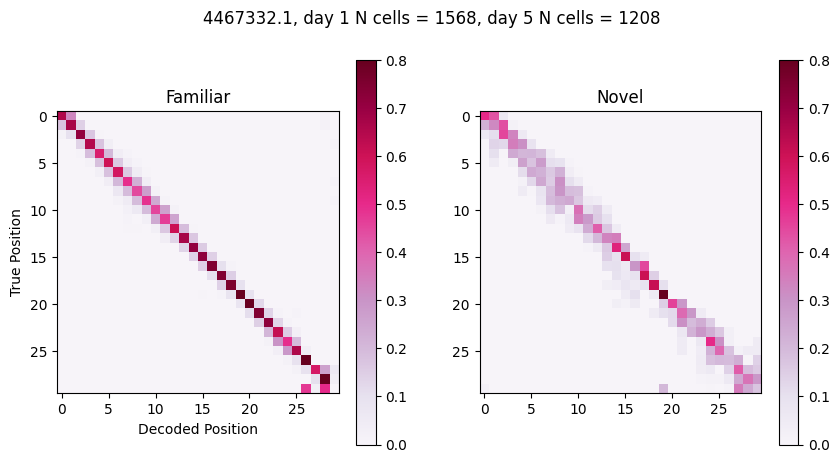

In [8]:
fig, ax = plt.subplots(1,2, figsize= [10, 5])
mouse = ctrl_mice[2]

sess = u.load_single_day(mouse,0)
nov_post = stx.naive_bayes.crossval(sess,nov=True)
ncells_0 = sess.timeseries['F_dff'].shape[0]

sess = u.load_single_day(mouse,4)
fam_post = stx.naive_bayes.crossval(sess,nov=False)
ncells_4 = sess.timeseries['F_dff'].shape[0]
    
h = ax[0].imshow(fam_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0], shrink=1.)
h = ax[1].imshow(nov_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1], shrink =1.)


fig.suptitle(f"{mouse}, day 1 N cells = {ncells_0}, day 5 N cells = {ncells_4}")
ax[0].set_title("Familiar")
ax[0].set_xlabel('Decoded Position')
ax[0].set_ylabel('True Position')

ax[1].set_title("Novel")

fig.savefig(figdir / f"{mouse}_naive_bayes_examples.pdf", bbox_inches='tight')

{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


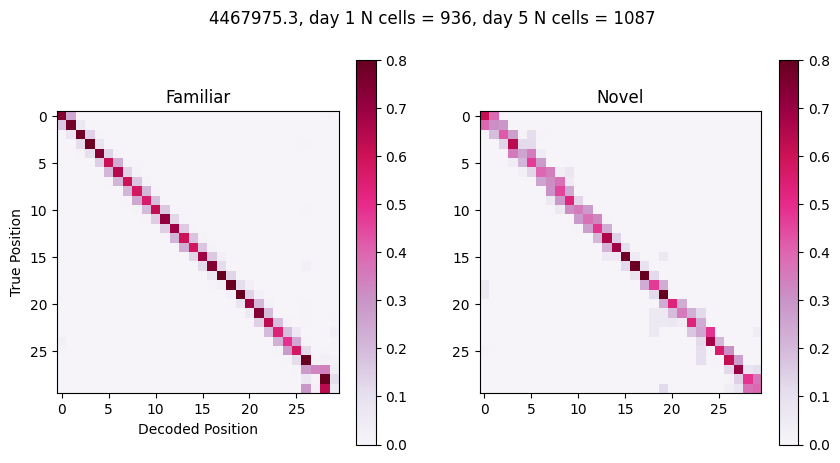

In [9]:
fig, ax = plt.subplots(1,2, figsize= [10, 5])
mouse = ko_mice[2]

sess = u.load_single_day(mouse,0)
nov_post = stx.naive_bayes.crossval(sess,nov=True)
ncells_0 = sess.timeseries['F_dff'].shape[0]

sess = u.load_single_day(mouse,4)
fam_post = stx.naive_bayes.crossval(sess,nov=False)
ncells_4 = sess.timeseries['F_dff'].shape[0]

    
h = ax[0].imshow(fam_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0], shrink=1.)
h = ax[1].imshow(nov_post.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1], shrink =1.)

fig.suptitle(f"{mouse}, day 1 N cells = {ncells_0}, day 5 N cells = {ncells_4}")
ax[0].set_title("Familiar")
ax[0].set_xlabel('Decoded Position')
ax[0].set_ylabel('True Position')

ax[1].set_title("Novel")

fig.savefig(figdir / f"{mouse}_naive_bayes_examples.pdf", bbox_inches='tight')

In [14]:
len(sparse_mice)

7

{'date': '26_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 11, 'novel_arm': -1, 'exp_day': 1}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 32, 'novel_arm': -1, 'exp_day': 5}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


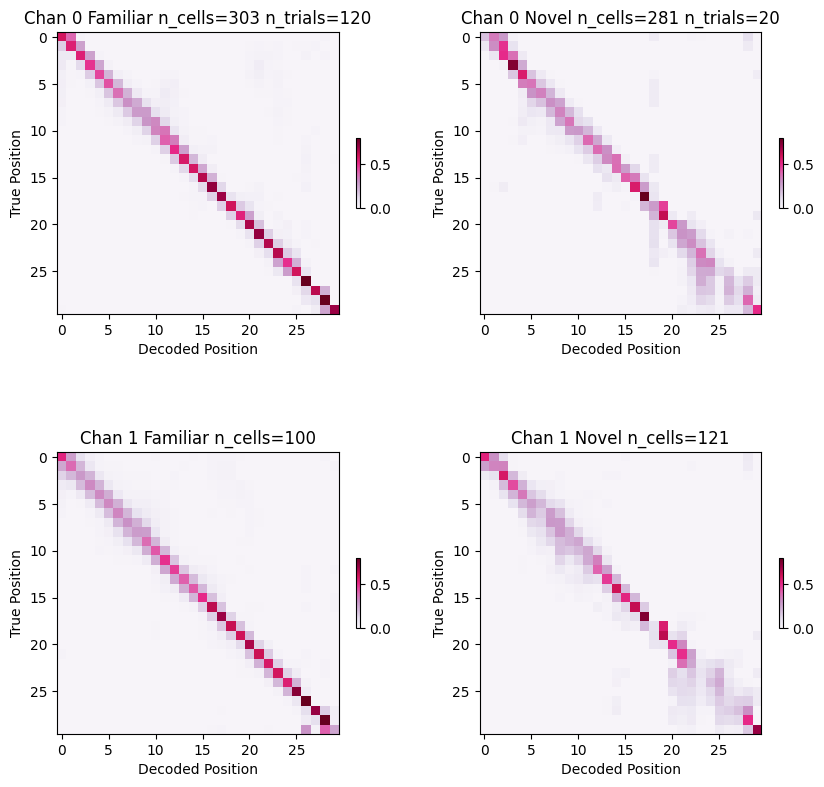

In [12]:
fig, ax = plt.subplots(2,2, figsize= [10,10])
mouse = sparse_mice[2]

sess = u.load_single_day(mouse,0)
nov_post_chan0 = stx.naive_bayes.crossval(sess,nov=True, chan='channel_0')
nov_post_chan1 = stx.naive_bayes.crossval(sess,nov=True, chan='channel_1')
ncells_0_chan0 = sess.timeseries['channel_0_F_dff'].shape[0]
ncells_0_chan1 = sess.timeseries['channel_1_F_dff'].shape[0]
n_trials_0 = (sess.trial_info['LR']==sess.novel_arm).sum()

sess = u.load_single_day(mouse,4)
fam_post_chan0 = stx.naive_bayes.crossval(sess,nov=False, chan='channel_0')
fam_post_chan1 = stx.naive_bayes.crossval(sess,nov=False, chan='channel_1')
ncells_4_chan0 = sess.timeseries['channel_0_F_dff'].shape[0]
ncells_4_chan1 = sess.timeseries['channel_1_F_dff'].shape[0]
n_trials_4 = (sess.trial_info['LR']!=sess.novel_arm).sum()

h = ax[0,0].imshow(fam_post_chan0.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0,0], shrink=.2)
h = ax[0,1].imshow(nov_post_chan0.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[0,1], shrink =.2)

h = ax[1,0].imshow(fam_post_chan1.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1,0], shrink=.2)
h = ax[1,1].imshow(nov_post_chan1.mean(axis=0), cmap='PuRd', vmin=0,vmax=.8)
plt.colorbar(h, ax = ax[1,1], shrink =.2)



ax[0,0].set_title(f"Chan 0 Familiar n_cells={ncells_4_chan0} n_trials={n_trials_4}")
ax[0,0].set_xlabel('Decoded Position')
ax[0,0].set_ylabel('True Position')

ax[0,1].set_title(f"Chan 0 Novel n_cells={ncells_0_chan0} n_trials={n_trials_0}")
ax[0,1].set_xlabel('Decoded Position')
ax[0,1].set_ylabel('True Position')


ax[1,0].set_title(f"Chan 1 Familiar n_cells={ncells_4_chan1}")
ax[1,0].set_xlabel('Decoded Position')
ax[1,0].set_ylabel('True Position')

ax[1,1].set_title(f"Chan 1 Novel n_cells={ncells_0_chan1}")
ax[1,1].set_xlabel('Decoded Position')
ax[1,1].set_ylabel('True Position')


fig.savefig(figdir / f"{mouse}_naive_bayes_examples.pdf", bbox_inches='tight')
# fig.suptitle(f"{mouse},channel 0: N cells = {ncells}")


# cross val with matched model size

In [6]:
ctrl_alldays_crossval = stx.naive_bayes.run_alldays_baseline_crossval(ctrl_mice, 128)
ko_alldays_crossval = stx.naive_bayes.run_alldays_baseline_crossval(ko_mice, 128)

mouse 4467331.1
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}


...

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 4}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


In [15]:
df = {
     'cond': [],
     'day': [],
     'ttype': [],
     'err': [],
     'mouse': [],
     }


days = np.arange(6)



for i, day in enumerate(days):
    for nov in ('fam','nov'):
        for m, mouse in enumerate(ko_mice):
            base_err = 10*stx.naive_bayes.abs_err(ko_alldays_crossval[mouse][day][nov])
            df['mouse'].append(mouse)
            df['cond'].append('ko')
            df['ttype'].append(nov)
            df['err'].append(base_err.mean())
            df['day'].append(day)
        for m, mouse in enumerate(ctrl_mice):
            base_err = 10*stx.naive_bayes.abs_err(ctrl_alldays_crossval[mouse][day][nov])
            df['mouse'].append(mouse)
            df['cond'].append('ctrl')
            df['ttype'].append(nov)
            df['err'].append(base_err.mean())
            df['day'].append(day)
                        
df = pd.DataFrame(df)


In [16]:
df.head()


,cond,day,ttype,err,mouse
0,ko,0,fam,27.157843,4467975.1
1,ko,0,fam,18.196970,4467975.2
2,ko,0,fam,16.216078,4467975.3
3,ko,0,fam,18.065432,4467975.4
4,ko,0,fam,31.617361,4467975.5


In [17]:
# save dataframe
df.to_pickle('/home/mplitt/shuffle_pkls/dense_naive_bayes_results.pkl')

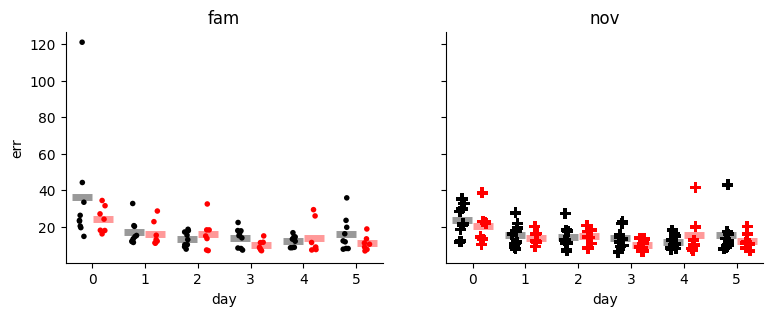

In [19]:
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='err',
                hue='cond', 
                hue_order=('ctrl', 'ko'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i], marker = marker, s=s,
                legend=False)
    


    sns.pointplot(data=df.loc[df['ttype']==nov,:],
              x='day',
              y='err',
              errorbar=None,
              hue='cond',
              hue_order = ['ctrl', 'ko'],
              dodge = .4,
              palette = ['black', 'red'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)



fig.savefig(figdir / f"naive_bayes_summary_128cells.pdf", bbox_inches='tight')

In [51]:
import statsmodels.formula.api as smf

df['err_rank'] = df['err'].rank()

# mdl = smf.mixedlm('err_rank ~ C(cond)*C(ttype) + C(ttype)*C(day) + C(cond)*C(day)', df, groups=df['mouse'])

mdl = smf.mixedlm('err_rank ~ C(cond)*C(ttype)*C(day)', df, groups=df['mouse'])
res = mdl.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                          Mixed Linear Model Regression Results
=========================================================================================
Model:                        MixedLM            Dependent Variable:            err_rank 
No. Observations:             192                Method:                        REML     
No. Groups:                   16                 Scale:                         1175.9467
Min. group size:              12                 Log-Likelihood:                -875.7642
Max. group size:              12                 Converged:                     Yes      
Mean group size:              12.0                                                       
-----------------------------------------------------------------------------------------
                                           Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
-----------------------------------------------------------------------------------------
Intercept                                  165.000   16.622  9.927 0.000  132.422 197.578
C(cond)[T.ko]                               -7.143   25.130 -0.284 0.776  -56.397  42.111
C(ttype)[T.nov]                            -16.111   16.165 -0.997 0.319  -47.795  15.573
C(day)[T.1]                                -49.444   16.165 -3.059 0.002  -81.128 -17.761
C(day)[T.2]                                -78.333   16.165 -4.846 0.000 -110.017 -46.650
C(day)[T.3]                                -72.333   16.165 -4.475 0.000 -104.017 -40.650
C(day)[T.4]                                -85.889   16.165 -5.313 0.000 -117.573 -54.205
C(day)[T.5]                                -70.222   16.165 -4.344 0.000 -101.906 -38.539
C(cond)[T.ko]:C(ttype)[T.nov]               -9.317   24.440 -0.381 0.703  -57.219  38.584
C(cond)[T.ko]:C(day)[T.1]                   -0.698   24.440 -0.029 0.977  -48.600  47.203
C(cond)[T.ko]:C(day)[T.2]                   19.333   24.440  0.791 0.429  -28.568  67.235
C(cond)[T.ko]:C(day)[T.3]                  -38.238   24.440 -1.565 0.118  -86.139   9.663
C(cond)[T.ko]:C(day)[T.4]                    2.175   24.440  0.089 0.929  -45.727  50.076
C(cond)[T.ko]:C(day)[T.5]                  -27.349   24.440 -1.119 0.263  -75.250  20.552
C(ttype)[T.nov]:C(day)[T.1]                  3.333   22.861  0.146 0.884  -41.474  48.141
C(ttype)[T.nov]:C(day)[T.2]                 19.000   22.861  0.831 0.406  -25.807  63.807
C(ttype)[T.nov]:C(day)[T.3]                 12.778   22.861  0.559 0.576  -32.030  57.585
C(ttype)[T.nov]:C(day)[T.4]                  7.667   22.861  0.335 0.737  -37.141  52.474
C(ttype)[T.nov]:C(day)[T.5]                  7.889   22.861  0.345 0.730  -36.919  52.696
C(cond)[T.ko]:C(ttype)[T.nov]:C(day)[T.1]   10.667   34.563  0.309 0.758  -57.076  78.409
C(cond)[T.ko]:C(ttype)[T.nov]:C(day)[T.2]   11.286   34.563  0.327 0.744  -56.457  79.028
C(cond)[T.ko]:C(ttype)[T.nov]:C(day)[T.3]   12.365   34.563  0.358 0.721  -55.377  80.108
C(cond)[T.ko]:C(ttype)[T.nov]:C(day)[T.4]   23.190   34.563  0.671 0.502  -44.552  90.933
C(cond)[T.ko]:C(ttype)[T.nov]:C(day)[T.5]   28.397   34.563  0.822 0.411  -39.346  96.139
Group Var                                 1310.631   16.216                              
=========================================================================================

"""

In [52]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                            chi2                 P>chi2  df constraint
Intercept                   [[98.5390447676904]]  3.186790011550351e-23              1
C(cond)                  [[0.08079089988167823]]     0.7762284554083463              1
C(ttype)                  [[0.9932895612636112]]     0.3189397039062202              1
C(day)                     [[38.05268293876645]]  3.682398310143686e-07              5
C(cond):C(ttype)         [[0.14534431409676435]]     0.7030248042304568              1
C(cond):C(day)             [[7.550400106603998]]    0.18281673650666663              5
C(ttype):C(day)           [[0.8745672465213822]]     0.9720354784730582              5
C(cond):C(ttype):C(day)   [[0.8509540523479988]]     0.9736701409535998              5

Shapiro-Wilk: W=0.994, p=0.65
D'Agostino: χ²=1.768, p=0.413


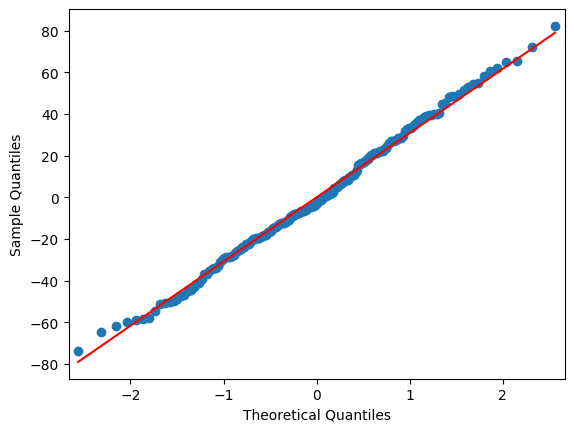

In [53]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [31]:
sparse_alldays_crossval = stx.naive_bayes.run_alldays_baseline_crossval_sparse(sparse_mice, 128)

mouse SparseKO_02
{'date': '16_11_2024', 'scene': 'YMaze_LNovel', 'session': 4, 'scan': 14, 'novel_arm': -1, 'exp_day': 1}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '17_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 25, 'novel_arm': -1, 'exp_day': 2}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '18_11_2024', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 18, 'novel_arm': -1, 'exp_day': 3}


...

/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '29_05_2025', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 14, 'novel_arm': -1, 'exp_day': 5}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


{'date': '30_05_2025', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 37, 'novel_arm': -1, 'exp_day': 6}


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/naive_bayes.py:28: RuntimeWarning: All-NaN slice encountered
  trial_mat -= np.nanmin(trial_mat,axis=-1,keepdims=True)


In [32]:
df_sparse = {
     'chan': [],
     'day': [],
     'ttype': [],
     'err': [],
     'mouse': [],
     }

days = np.arange(6)

for i, day in enumerate(days):
    for nov in ('fam','nov'):
        for chan in ('channel_0','channel_1'):
            for m, mouse in enumerate(sparse_mice):
                if mouse == 'SparseKO_09' and day ==2:
                    continue
                
                base_err = 10*stx.naive_bayes.abs_err(sparse_alldays_crossval[mouse][day][chan][nov])
                df_sparse['mouse'].append(mouse)
                df_sparse['chan'].append(chan)
                df_sparse['ttype'].append(nov)
                df_sparse['err'].append(base_err.mean())
                df_sparse['day'].append(day)
        
df_sparse = pd.DataFrame(df_sparse)


In [33]:
df.to_pickle('/home/mplitt/shuffle_pkls/sparse_naive_bayes_results.pkl')

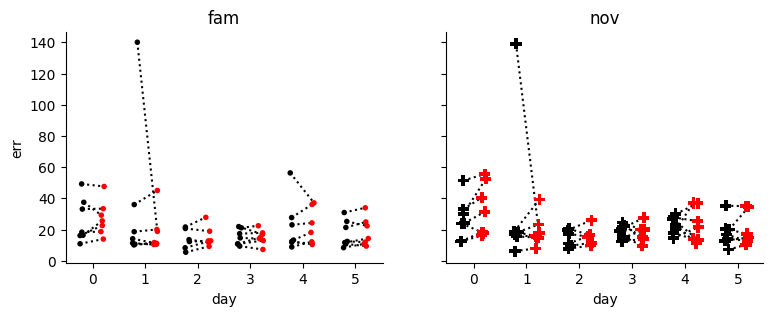

In [38]:
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df_sparse.loc[df_sparse['ttype']==nov,:],
                x='day',
                y='err',
                hue='chan', 
                hue_order=('channel_1', 'channel_0'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax[i], marker = marker, s=s,
                legend=False)
    
    ax[i].set_title(nov)
    for d in range(0,12,2):
        for (x0, y0), (x1, y1) in zip(ax[i].collections[d].get_offsets(), ax[i].collections[d+1].get_offsets()):
            ax[i].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)



fig.savefig(figdir / f"sparse_naive_bayes_summary_128cells.pdf", bbox_inches='tight')


In [44]:
df_sparse['err_rank'] = df_sparse['err'].rank()

mdl = smf.mixedlm('err_rank ~ C(chan)*C(ttype) + C(ttype)*C(day) ', df_sparse, groups=df_sparse['mouse'])
res = mdl.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                       Mixed Linear Model Regression Results
===================================================================================
Model:                      MixedLM          Dependent Variable:          err_rank 
No. Observations:           164              Method:                      REML     
No. Groups:                 7                Scale:                       854.8929 
Min. group size:            20               Log-Likelihood:              -748.6311
Max. group size:            24               Converged:                   Yes      
Mean group size:            23.4                                                   
-----------------------------------------------------------------------------------
                                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
-----------------------------------------------------------------------------------
Intercept                             113.200   16.002  7.074 0.000  81.836 144.565
C(chan)[T.channel_1]                   -4.829    6.458 -0.748 0.455 -17.486   7.828
C(ttype)[T.nov]                         3.636   11.957  0.304 0.761 -19.800  27.072
C(day)[T.1]                           -40.357   11.051 -3.652 0.000 -62.017 -18.697
C(day)[T.2]                           -48.639   11.545 -4.213 0.000 -71.268 -26.011
C(day)[T.3]                           -47.357   11.051 -4.285 0.000 -69.017 -25.697
C(day)[T.4]                           -28.500   11.051 -2.579 0.010 -50.160  -6.840
C(day)[T.5]                           -39.214   11.051 -3.548 0.000 -60.874 -17.554
C(chan)[T.channel_1]:C(ttype)[T.nov]    4.585    9.133  0.502 0.616 -13.314  22.485
C(ttype)[T.nov]:C(day)[T.1]             6.643   15.629  0.425 0.671 -23.989  37.274
C(ttype)[T.nov]:C(day)[T.2]            -3.095   16.267 -0.190 0.849 -34.978  28.787
C(ttype)[T.nov]:C(day)[T.3]            16.000   15.629  1.024 0.306 -14.632  46.632
C(ttype)[T.nov]:C(day)[T.4]            15.429   15.629  0.987 0.324 -15.203  46.060
C(ttype)[T.nov]:C(day)[T.5]             0.286   15.629  0.018 0.985 -30.346  30.917
Group Var                            1292.130   26.774                             
===================================================================================

"""

In [45]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                     chi2                  P>chi2  df constraint
Intercept          [[50.040420041605415]]  1.5061131423099296e-12              1
C(chan)            [[0.5592484592954373]]     0.45456320829078123              1
C(ttype)          [[0.09245918072488665]]      0.7610737904272169              1
C(day)             [[26.408693699893796]]    7.43378832596954e-05              5
C(chan):C(ttype)  [[0.25209261230152363]]      0.6156054439964931              1
C(ttype):C(day)    [[2.6923999374321634]]      0.7472805857144642              5

Shapiro-Wilk: W=0.991, p=0.381
D'Agostino: χ²=0.009, p=0.995


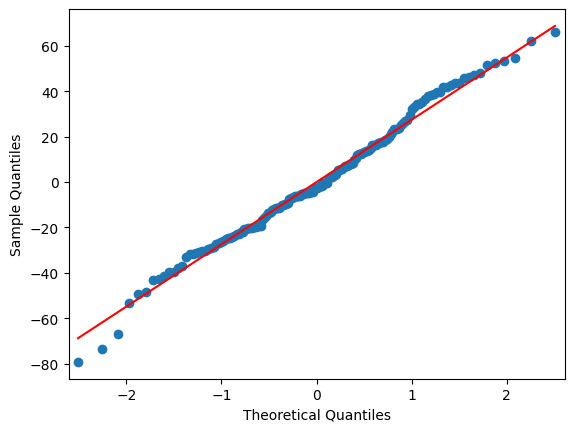

In [47]:
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [42]:
aov = pg.rm_anova(df_sparse.loc[df_sparse['ttype']=='fam'], subject='mouse', dv='err_rank', 
                  within=['chan', 'day'])
aov

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,chan,430.222222,1,5,430.222222,0.395999,0.556791,0.556791,0.002953,1.000000
1,day,18022.611111,5,25,3604.522222,5.864423,0.001022,0.010537,0.110389,0.530494
2,chan * day,1503.111111,5,25,300.622222,1.878628,0.134087,0.171608,0.010243,0.640722


In [43]:
aov = pg.rm_anova(df_sparse.loc[df_sparse['ttype']=='nov'], subject='mouse', dv='err_rank', 
                  within=['chan', 'day'])
aov

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,chan,23.347222,1,5,23.347222,0.009492,0.926171,0.926171,0.000208,1.000000
1,day,21473.069444,5,25,4294.613889,4.414419,0.005108,0.039182,0.160819,0.420542
2,chan * day,2359.736111,5,25,471.947222,1.058794,0.406318,0.375329,0.020625,0.332102
